In [ ]:
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [1]:
import scanpy as sc
import numpy as np
from scipy.stats import pearsonr, linregress
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib


import json
import os
import gc
from tqdm import tqdm

# Read original data & normalize

In [2]:
# read
adata = sc.read_h5ad('../../Datasets/preprocessed_datasets/norman.h5ad')

# normalize
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# to numpy
adata.X = adata.X.toarray()

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
adata.X seems to be already log-transformed.


# Quantify systematic variation

In [3]:
ctrl_mean = adata[adata.obs['cond_harm'] == 'ctrl'].X.mean(axis=0)
pert_mean = adata[adata.obs['cond_harm'] != 'ctrl'].X.mean(axis=0)
sys_delta = pert_mean - ctrl_mean

# Compute correlation of each pert delta with sys_delta

In [4]:
perts = adata.obs['cond_harm'].unique().tolist()
double_perts = [x for x in perts if '+' in x]
len(double_perts)

128

In [5]:
pert_variations = {}
for pert in tqdm(double_perts):
    subset = adata[adata.obs['cond_harm'] == pert].copy()
    p_delta = subset.X.mean(axis=0) - ctrl_mean
    sim = np.dot(p_delta, sys_delta) / (np.linalg.norm(p_delta) * np.linalg.norm(sys_delta))
    pert_variations[pert] = sim

    del subset
    gc.collect()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [01:14<00:00,  1.73it/s]


In [6]:
pert_variations = dict(sorted(pert_variations.items(), key=lambda item: item[1]))

# Correlation with systematic variation

In [7]:
def get_corr(
    pert_variations,
    metric,
    scenario,
    method,
):
    base_dir = f'../../Benchmarks/y_pred_results/results/Norman/{scenario}/{method}'

    gt = []
    pred = []
    for pert in tqdm(pert_variations.keys()):
        if os.path.isfile(f'{base_dir}/{pert}.csv'):
            _results = pd.read_csv(f'{base_dir}/{pert}.csv')
            _results.set_index('Metric', inplace=True)
            pred_val = _results.loc[metric, '20']
            pred.append(pred_val)
            gt.append(pert_variations[pert])

    pcorr, _ = pearsonr(pred, gt)

    print(f'Correlation of {method} on {metric} in {scenario} is {pcorr}')
    return {
        'pred':pred,
        'gt':gt,
        'correlation':pcorr
    }

In [8]:
cpa_corr = get_corr(
    pert_variations=pert_variations,
    metric='Pearson Mean Delta',
    scenario='combinatorially_seen',
    method='CPA'
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 1440.86it/s]

Correlation of CPA on Pearson Mean Delta in combinatorially_seen is 0.6001578977695285


In [9]:
gears_corr = get_corr(
    pert_variations=pert_variations,
    metric='Pearson Mean Delta',
    scenario='combinatorially_seen',
    method='GEARS'
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 1482.11it/s]

Correlation of GEARS on Pearson Mean Delta in combinatorially_seen is 0.4504516352012068


In [10]:
scdisentangle_corr = get_corr(
    pert_variations=pert_variations,
    metric='Pearson Mean Delta',
    scenario='combinatorially_seen',
    method='SCDISENTANGLE'
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 1486.38it/s]

Correlation of SCDISENTANGLE on Pearson Mean Delta in combinatorially_seen is 0.23218708953408965


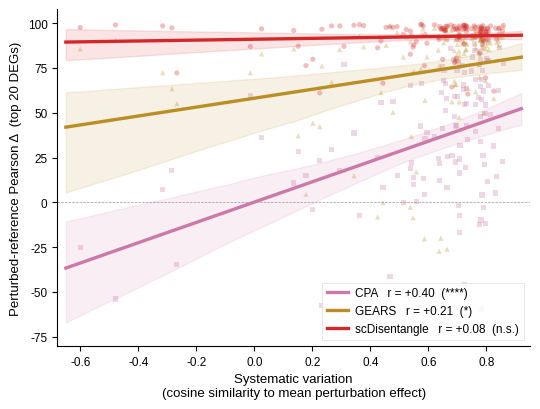

In [11]:
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

scenario = 'combinatorially_seen'
metric   = 'Perturbed Reference Pearson Delta'
deg_col  = '20'

palette = {
    'scDisentangle': '#d62728',
    'CPA':           '#CC79A7',
    'GEARS':         '#BA8E23',
}
markers = {'scDisentangle': 'o', 'CPA': 's', 'GEARS': '^'}
folders = {'scDisentangle': 'SCDISENTANGLE', 'CPA': 'CPA', 'GEARS': 'GEARS'}

# get data
method_data = {}
for label in palette:
    base = f'../../Benchmarks/y_pred_results/results/Norman/{scenario}/{folders[label]}'
    xs, ys = [], []
    for pert, sv in pert_variations.items():
        fpath = f'{base}/{pert}.csv'
        if os.path.isfile(fpath):
            df = pd.read_csv(fpath).set_index('Metric')
            if metric in df.index:
                xs.append(sv)
                ys.append(df.loc[metric, deg_col])
    method_data[label] = (np.array(xs), np.array(ys))

# bootstrap confidence bands 
def bootstrap_band(xs, ys, x_grid, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(xs)
    y_boots = np.zeros((n_boot, len(x_grid)))
    for i in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        sl, ic = np.polyfit(xs[idx], ys[idx], 1)
        y_boots[i] = sl * x_grid + ic
    lo = np.percentile(y_boots, 2.5, axis=0)
    hi = np.percentile(y_boots, 97.5, axis=0)
    return lo, hi

# plt
fig, ax = plt.subplots(figsize=(5.5, 4.2))

x_grid = np.linspace(-0.65, 0.92, 200)
draw_order = ['CPA', 'GEARS', 'scDisentangle']

for label in draw_order:
    xs, ys = method_data[label]
    color  = palette[label]
    marker = markers[label]

    # scatter
    ax.scatter(xs, ys, c=color, marker=marker, s=14, alpha=0.30,
               edgecolors='none', zorder=2)

    # Regression
    sl, ic = np.polyfit(xs, ys, 1)
    r, p   = pearsonr(xs, ys)
    y_line = sl * x_grid + ic

    # confidence band
    lo, hi = bootstrap_band(xs, ys, x_grid)
    ax.fill_between(x_grid, lo, hi, color=color, alpha=0.12, zorder=1)

    # reg line
    sig = "****" if p <0.0001 else ('***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')))
    ax.plot(x_grid, y_line, color=color, lw=2.4, zorder=3,
            label=f'{label}   r = {r:+.2f}  ({sig})')

# 0 line
ax.axhline(0, color='#999999', lw=0.5, ls='--', zorder=0)

# Axes
ax.set_xlabel('Systematic variation\n(cosine similarity to mean perturbation effect)',
              fontsize=9.5)
ax.set_ylabel('Perturbed-reference Pearson Δ  (top 20 DEGs)', fontsize=9.5)
ax.set_xlim(-0.68, 0.95)
ax.tick_params(labelsize=8.5)

leg = ax.legend(fontsize=8.5, frameon=True, fancybox=False,
                edgecolor='#dddddd', loc='lower right',
                handlelength=1.8, handletextpad=0.6)
leg.get_frame().set_linewidth(0.6)

# remove spine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.savefig(f'{FIG_ROOT}/Norman/systematic_variation_{metric}.svg', dpi=600)
plt.show()

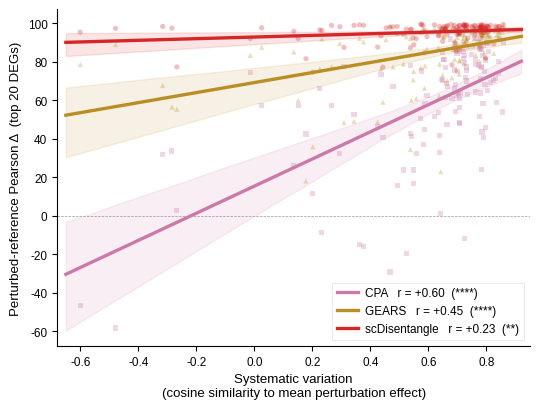

In [13]:
scenario = 'combinatorially_seen'
metric   = 'Pearson Mean Delta'
deg_col  = '20'

palette = {
    'scDisentangle': '#d62728',
    'CPA':           '#CC79A7',
    'GEARS':         '#BA8E23',
}
markers = {'scDisentangle': 'o', 'CPA': 's', 'GEARS': '^'}
folders = {'scDisentangle': 'SCDISENTANGLE', 'CPA': 'CPA', 'GEARS': 'GEARS'}

# get data
method_data = {}
for label in palette:
    base = f'../../Benchmarks/y_pred_results/results/Norman/{scenario}/{folders[label]}'
    xs, ys = [], []
    for pert, sv in pert_variations.items():
        fpath = f'{base}/{pert}.csv'
        if os.path.isfile(fpath):
            df = pd.read_csv(fpath).set_index('Metric')
            if metric in df.index:
                xs.append(sv)
                ys.append(df.loc[metric, deg_col])
    method_data[label] = (np.array(xs), np.array(ys))

# bootstrap confidence bands 
def bootstrap_band(xs, ys, x_grid, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(xs)
    y_boots = np.zeros((n_boot, len(x_grid)))
    for i in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        sl, ic = np.polyfit(xs[idx], ys[idx], 1)
        y_boots[i] = sl * x_grid + ic
    lo = np.percentile(y_boots, 2.5, axis=0)
    hi = np.percentile(y_boots, 97.5, axis=0)
    return lo, hi

# plt
fig, ax = plt.subplots(figsize=(5.5, 4.2))

x_grid = np.linspace(-0.65, 0.92, 200)
draw_order = ['CPA', 'GEARS', 'scDisentangle']

for label in draw_order:
    xs, ys = method_data[label]
    color  = palette[label]
    marker = markers[label]

    # scatter
    ax.scatter(xs, ys, c=color, marker=marker, s=14, alpha=0.30,
               edgecolors='none', zorder=2)

    # Regression
    sl, ic = np.polyfit(xs, ys, 1)
    r, p   = pearsonr(xs, ys)
    y_line = sl * x_grid + ic

    # confidence band
    lo, hi = bootstrap_band(xs, ys, x_grid)
    ax.fill_between(x_grid, lo, hi, color=color, alpha=0.12, zorder=1)

    # reg line
    sig = "****" if p <0.0001 else ('***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')))
    ax.plot(x_grid, y_line, color=color, lw=2.4, zorder=3,
            label=f'{label}   r = {r:+.2f}  ({sig})')

# 0 line
ax.axhline(0, color='#999999', lw=0.5, ls='--', zorder=0)

# Axes
ax.set_xlabel('Systematic variation\n(cosine similarity to mean perturbation effect)',
              fontsize=9.5)
ax.set_ylabel('Perturbed-reference Pearson Δ  (top 20 DEGs)', fontsize=9.5)
ax.set_xlim(-0.68, 0.95)
ax.tick_params(labelsize=8.5)

leg = ax.legend(fontsize=8.5, frameon=True, fancybox=False,
                edgecolor='#dddddd', loc='lower right',
                handlelength=1.8, handletextpad=0.6)
leg.get_frame().set_linewidth(0.6)

# remove spine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.savefig(f'{FIG_ROOT}/Norman/systematic_variation_{metric}.svg', dpi=600)
plt.show()

In [15]:
cpa_corr = get_corr(
    pert_variations=pert_variations,
    metric='Perturbed Reference Pearson Delta',
    scenario='combinatorially_seen',
    method='CPA'
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 1501.01it/s]

Correlation of CPA on Perturbed Reference Pearson Delta in combinatorially_seen is 0.40397478777860474


In [16]:
cpa_corr = get_corr(
    pert_variations=pert_variations,
    metric='Perturbed Reference Pearson Delta',
    scenario='combinatorially_seen',
    method='SCDISENTANGLE'
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 1250.37it/s]

Correlation of SCDISENTANGLE on Perturbed Reference Pearson Delta in combinatorially_seen is 0.07854815792924486


In [17]:
cpa_corr = get_corr(
    pert_variations=pert_variations,
    metric='Perturbed Reference Pearson Delta',
    scenario='combinatorially_seen',
    method='GEARS'
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 1511.05it/s]

Correlation of GEARS on Perturbed Reference Pearson Delta in combinatorially_seen is 0.21239463305704787
